# Automatic Text Simplification for People with Aphasia

### Imports

The query I used for documents search was "text simplification AND aphasia AND transformers" because those topics are main for our research. The length of the dataset is around 1200 samples.

In [1]:
options(warn = -1)

suppressPackageStartupMessages(library(bibliometrix))
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(wordcloud))
suppressPackageStartupMessages(library(tm))
suppressPackageStartupMessages(library(SnowballC))
suppressPackageStartupMessages(library(topicmodels))
suppressPackageStartupMessages(library(tidytext))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(LDAvis))
suppressPackageStartupMessages(library(servr))
library(repr)

In [2]:
options(repr.plot.width = 10, repr.plot.height = 6)


### Load Data from Dimensions

In [3]:
data <- convert2df(
  "data/simplification_aphasia_ai.csv", dbsource = "dimensions", format = "csv"
)



Converting your dimensions collection into a bibliographic dataframe



Rows: 500 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (27): Publication ID, DOI, PMCID, Title, Abstract, Acknowledgements, Fun...
dbl  (7): Rank, PMID, PubYear, Times cited, Recent citations, RCR, FCR

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.



Creating ISO Source names...Done!


Generating affiliation field tag AU_UN from C1:  Done!


Removed  15 duplicated documents


### Let's Perform Basic Bibliometrix Analysis with Summary

In [4]:
results <- biblioAnalysis(data, sep = ";")

summary <- summary(object = results, k = 10, pause = FALSE)




MAIN INFORMATION ABOUT DATA

 Timespan                              1956 : 2025 
 Sources (Journals, Books, etc)        114 
 Documents                             485 
 Annual Growth Rate %                  0 
 Document Average Age                  12.9 
 Average citations per doc             13.81 
 Average citations per year per doc    1.237 
 References                            1 
 
DOCUMENT TYPES                     
 article          115 
 chapter          39 
 edited book      234 
 monograph        59 
 preprint         28 
 proceeding       10 
 
DOCUMENT CONTENTS
 Keywords Plus (ID)                    68 
 Author's Keywords (DE)                68 
 
AUTHORS
 Authors                               471 
 Author Appearances                    517 
 Authors of single-authored docs       108 
 
AUTHORS COLLABORATION
 Single-authored docs                  111 
 Documents per Author                  1.03 
 Co-Authors per Doc                    1.07 
 International co-authorships 

In [5]:
cat("\nMain Info:\n")
print(summary$MainInformationDF)


Main Info:
                          Description   Results
1         MAIN INFORMATION ABOUT DATA          
2                            Timespan 1956:2025
3      Sources (Journals, Books, etc)       114
4                           Documents       485
5                Annual Growth Rate %         0
6                Document Average Age      12.9
7           Average citations per doc     13.81
8  Average citations per year per doc     1.237
9                          References         1
10                     DOCUMENT TYPES          
11                            article       115
12                            chapter        39
13                        edited book       234
14                          monograph        59
15                           preprint        28
16                         proceeding        10
17                  DOCUMENT CONTENTS          
18                 Keywords Plus (ID)        68
19             Author's Keywords (DE)        68
20                          

The documents cover the period from 1956 to 2025.   There are 485 documents from 114 sources (journals, books, etc.).   The average citations per document are 13.81, and the average per year per document is 1.237, suggesting that the documents in this collection are moderately cited in the field.  A large proportion of the documents are edited books (234), followed by articles (115), chapters (39), monographs (59), and smaller numbers of other types.    There are 471 unique authors, with 517 total author appearances. The average document per author is 1.03, indicating that most authors contributed a single publication, and the international co-authorship percentage is quite low at 1.856%, suggesting limited global collaboration.

In [6]:
cat("\nMost Productive Authors:\n")
print(summary$MostProdAuthors)


Most Productive Authors:
    Authors        Articles Authors        Articles Fractionalized
1  MARTIN L               4     ROST M                        2.50
2  SAGOT B                4     STERIADE M                    2.00
3  BORDES A               3     UTTAL WR                      2.00
4  GRABAR N               3     GRABAR N                      1.33
5  GROUIN C               3     GROUIN C                      1.33
6  ROST M                 3     HUANG W                       1.25
7  ALARCON R              2     AGARWAL A                     1.00
8  ALONZO O               2     BAHUN S                       1.00
9  ALVA-MANCHEGO F        2     BALOH RW                      1.00
10 BAUERMEISTER H         2     BARNETT RL                    1.00


In [7]:
cat("\nMost Relevant Sources:\n")
print(summary$MostRelSources)


Most Relevant Sources:
                                       Sources        Articles
1  NA                                                      149
2  BEHAVIORAL AND BRAIN SCIENCES                            71
3  LECTURE NOTES IN COMPUTER SCIENCE                        51
4  ATHENA RESEARCH BOOKVOLUME 1                             30
5  ARXIV                                                    25
6  ADVANCES IN INTELLIGENT SYSTEMS AND COMPUTING            13
7  COMMUNICATIONS IN COMPUTER AND INFORMATION SCIENCE       11
8  LECTURE NOTES IN NETWORKS AND SYSTEMS                    10
9  LECTURE NOTES IN ELECTRICAL ENGINEERING                   5
10 SMART INNOVATION SYSTEMS AND TECHNOLOGIES                 3


"Behavioral and Brain Sciences" and "Lecture Notes in Computer Science" are prominent sources, with 71 and 51 articles respectively.
A significant number of documents (149) are categorized as "NA," which may indicate missing source information or sources that don’t neatly fit into predefined categories.
This list reflects a focus on cognitive science and computational disciplines, aligning well with your interdisciplinary research theme.

In [8]:
cat("\nAnnual Production:\n")
print(summary$AnnualProduction)


Annual Production:
   Year    Articles
1     1956        1
2     1964        1
3     1971        1
4     1972        1
5     1974        1
6     1975        2
7     1978       41
8     1979        1
9     1980        2
10    1982        1
11    1983        2
12    1984        1
13    1985        1
14    1986        2
15    1987        1
16    1988        1
17    1989        2
18    1990        2
19    1991        1
20    1992        3
21    1993        2
22    1994        4
23    1995        1
24    1996        2
25    1997        5
26    1998        3
27    1999       35
28    2000        2
29    2001        2
30    2002        2
31    2003        4
32    2004        7
33    2005        7
34    2006        1
35    2007        3
36    2008        3
37    2009        2
38    2010        5
39    2011        3
40    2012       13
41    2013       12
42    2014        8
43    2015       10
44    2016        6
45    2017       10
46    2018        5
47    2019       21
48    2020       31


In [9]:
cat("\nMost Cited Papers:\n")
print(summary$MostCitedPapers)


Most Cited Papers:
                                                 Paper                                              DOI  TC TCperYear
1  NA, 2004, NA                                                 10.1515/9780691236629                   671     31.95
2  NA, 1998, NA                                                 10.1007/978-1-4612-1664-3               289     10.70
3  SMITH ER, 1996, JOURNAL OF PERSONALITY AND SOCIAL PSYCHOLOGY 10.1037/0022-3514.70.5.893              264      9.10
4  SOKOLOV AN, 1972, MONOGRAPHS IN PSYCHOLOGY                   10.1007/978-1-4684-1914-6               261      4.92
5  GEE J, 2007, NA                                              10.4324/9780203944806                   232     12.89
6  NA, 1989, NA                                                 10.1007/978-3-642-73831-9               222      6.17
7  NA, 2014, NA-a-b                                             10.1093/OXFORDHB/9780199571932.001.0001 174     15.82
8  STERIADE M, 1978, BEHAVIORAL AND 

The top-cited paper (from 2004) has 671 citations, with a citation per year rate of 31.95. Several highly cited documents focus on psychology and cognitive science.
Papers by Smith ER (1996) and Sokolov AN (1972) are also heavily cited, showcasing influential literature possibly related to the theoretical or applied aspects of cognition and language processing.

In [10]:
cat("\nMost Productive Countries:\n")
print(summary$MostProdCountries)


Most Productive Countries:
          Country Articles   Freq SCP MCP MCP_Ratio
1  USA                   9 0.1385   9   0     0.000
2  FRANCE                8 0.1231   6   2     0.250
3  GERMANY               6 0.0923   5   1     0.167
4  CANADA                5 0.0769   4   1     0.200
5  CHINA                 5 0.0769   4   1     0.200
6  ITALY                 5 0.0769   5   0     0.000
7  JAPAN                 3 0.0462   3   0     0.000
8  UNITED KINGDOM        3 0.0462   3   0     0.000
9  HUNGARY               2 0.0308   2   0     0.000
10 SAUDI ARABIA          2 0.0308   1   1     0.500


The USA leads in productivity with 9 articles, followed by France with 8, and Germany with 6.
A metric, MCP (Multiple Country Publications) Ratio, shows the degree of international collaboration. Countries like France and Saudi Arabia have higher MCP ratios.

In [11]:
cat("\nMost Relevant keywords:\n")
print(summary$MostRelKeywords)


Most Relevant keywords:
           Author Keywords (DE)      Articles            Keywords-Plus (ID)     Articles
1  HUMANS                                  12 HUMANS                                  12
2  ARTIFICIAL INTELLIGENCE                  4 ARTIFICIAL INTELLIGENCE                  4
3  LANGUAGE                                 4 LANGUAGE                                 4
4  NATURAL LANGUAGE PROCESSING              4 NATURAL LANGUAGE PROCESSING              4
5  ALGORITHMS                               3 ALGORITHMS                               3
6  COGNITION                                3 COGNITION                                3
7  COVID-19                                 3 COVID-19                                 3
8  ELECTRONIC HEALTH RECORDS                2 ELECTRONIC HEALTH RECORDS                2
9  FEMALE                                   2 FEMALE                                   2
10 INFORMATION STORAGE AND RETRIEVAL        2 INFORMATION STORAGE AND RETRIEVAL      

## Graphics

### Annual Scientific Production

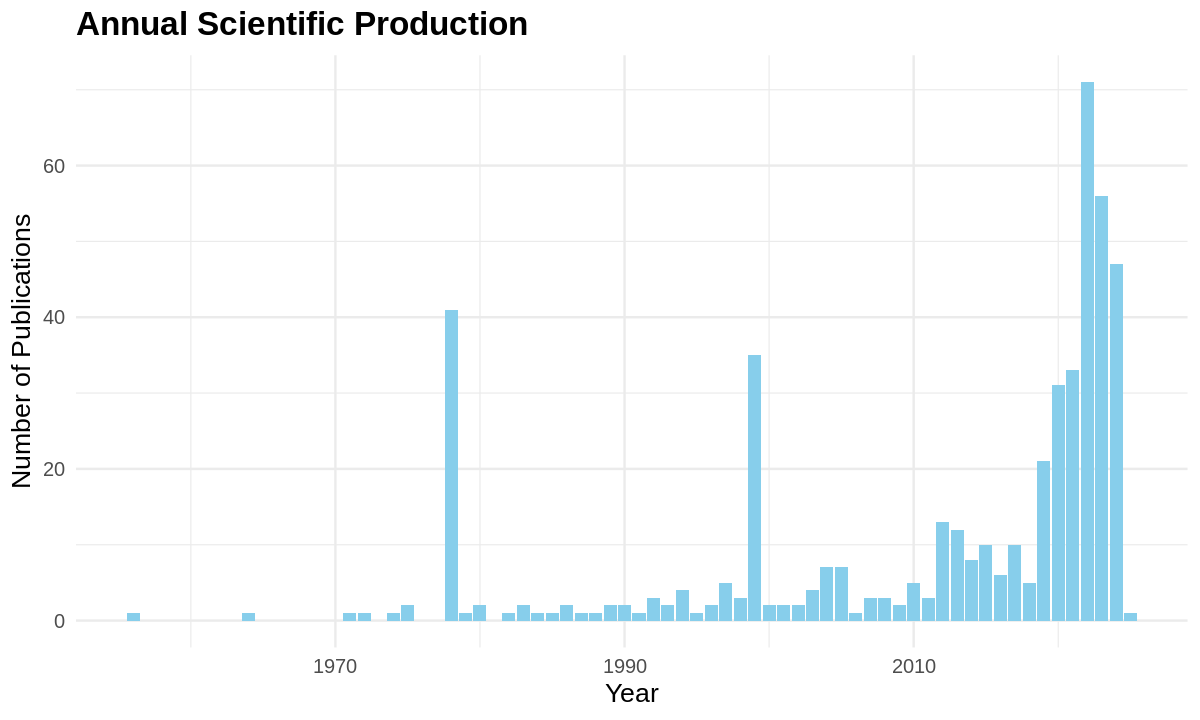

In [22]:
annual_prod <- data.frame(table(data$PY))
colnames(annual_prod) <- c("Year", "Frequency")
annual_prod$Year <- as.numeric(as.character(annual_prod$Year))
annual_prod <- annual_prod[order(annual_prod$Year), ]

ggplot(annual_prod, aes(x = Year, y = Frequency)) +
  geom_bar(stat = "identity", fill = "skyblue") +
  ggtitle("Annual Scientific Production") +
  xlab("Year") +
  ylab("Number of Publications") +
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(size = 20, face = "bold"),
    axis.title.x = element_text(size = 16),
    axis.title.y = element_text(size = 16),
    axis.text.x = element_text(size = 12),
    axis.text.y = element_text(size = 12)
  )


### Most Relevant Authors

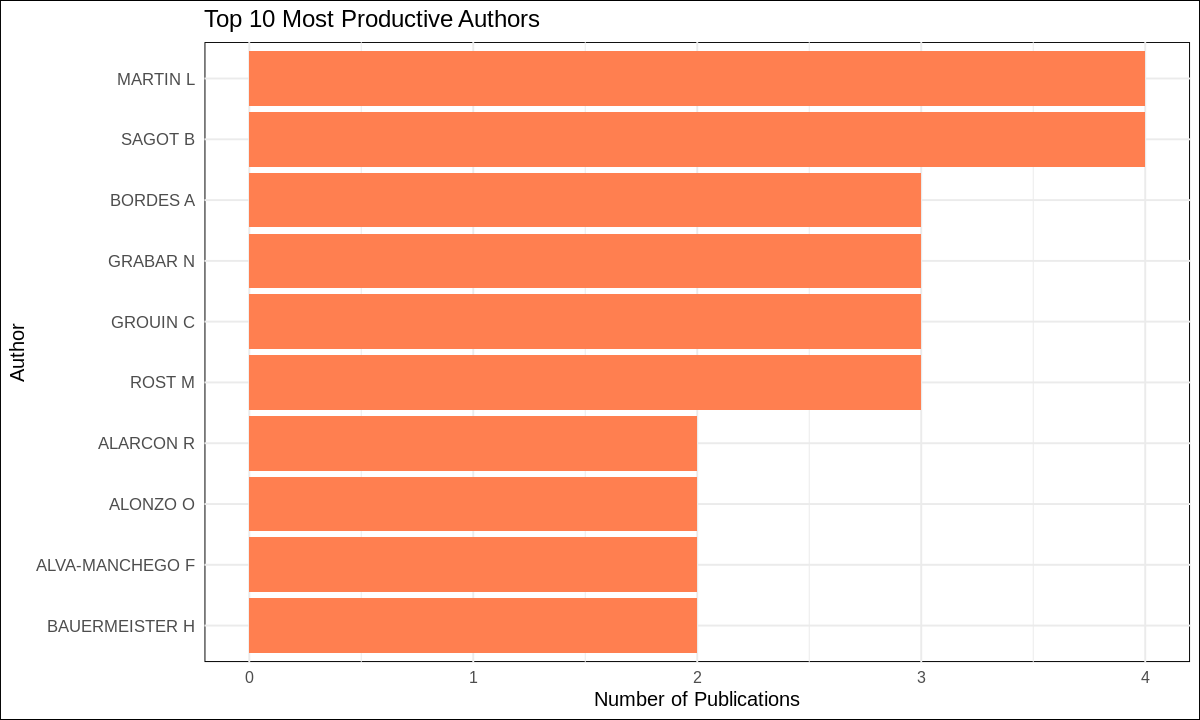

In [13]:
authors_list <- strsplit(as.character(data$AU), ";")

authors_vector <- trimws(unlist(authors_list))

authors_vector <- authors_vector[authors_vector != "" & !is.na(authors_vector)]

author_counts <- sort(table(authors_vector), decreasing = TRUE)

top_authors <- data.frame(
  Author = names(author_counts)[1:10],
  Frequency = as.numeric(author_counts)[1:10],
  stringsAsFactors = FALSE
)
top_authors$Author <- factor(
  top_authors$Author, levels = rev(top_authors$Author)
)


ggplot(top_authors, aes(x = Author, y = Frequency)) +
  geom_bar(stat = "identity", fill = "coral") +
  coord_flip() +
  ggtitle("Top 10 Most Productive Authors") +
  xlab("Author") +
  ylab("Number of Publications") +
  theme_minimal(base_size = 12) +
  theme(
    plot.background = element_rect(fill = "white"),
    panel.background = element_rect(fill = "white"),
    axis.text.y = element_text(size = 10)
  )


### Most Relevant Keywords

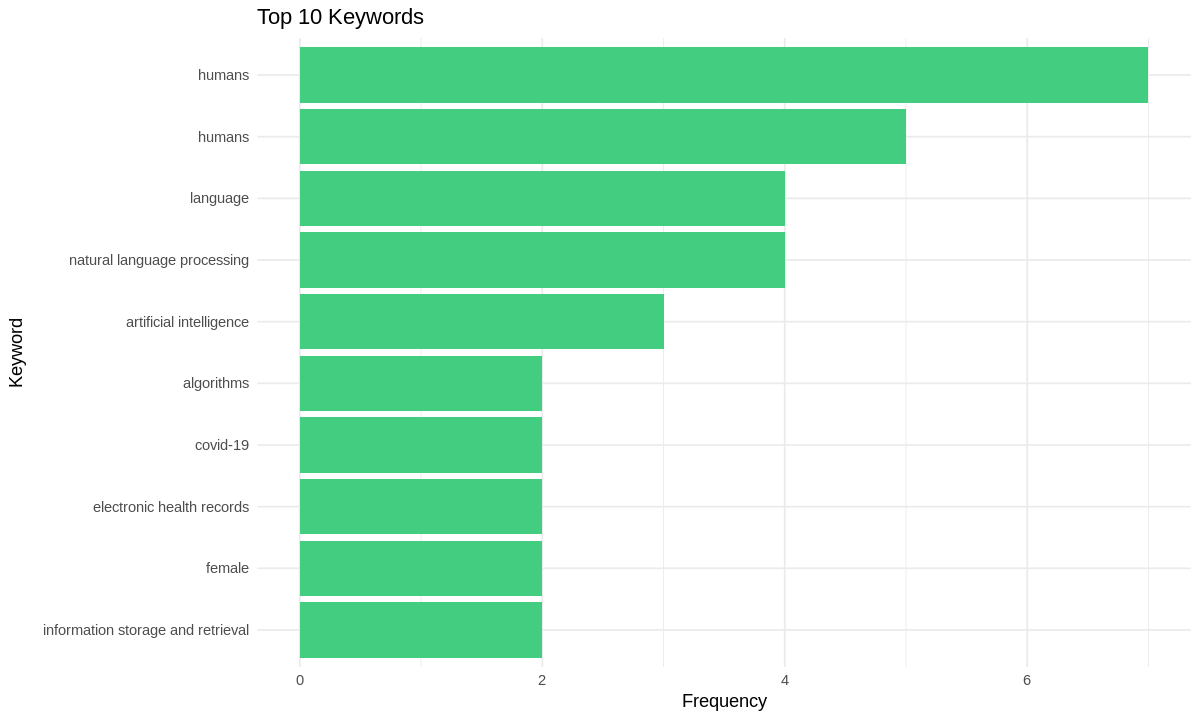

In [14]:
keywords <- strsplit(tolower(data$ID), ";")
keywords <- unlist(keywords)
keyword_freq <- sort(table(keywords), decreasing = TRUE)
top_keywords <- data.frame(keyword_freq[1:10])
colnames(top_keywords) <- c("Keyword", "Frequency")
top_keywords$Keyword <- factor(
  top_keywords$Keyword, levels = rev(top_keywords$Keyword)
)

ggplot(top_keywords, aes(x = Keyword, y = Frequency)) +
  geom_bar(stat = "identity", fill = "seagreen3") +
  coord_flip() +
  ggtitle("Top 10 Keywords") +
  xlab("Keyword") +
  ylab("Frequency") +
  theme_minimal()


### Country Collaboration Map

$graph
IGRAPH 53cc83f UNW- 10 9 -- 
+ attr: alpha (g/n), ylim (g/n), xlim (g/n), rescale (g/l), asp (g/n), layout (g/n), main (g/c), name
| (v/c), deg (v/n), size (v/n), label.cex (v/n), color (v/c), community (v/n), label.dist (v/n),
| frame.color (v/c), label.color (v/c), label.font (v/n), label (v/c), num (e/n), width (e/n), color (e/c),
| lty (e/n), weight (e/n), curved (e/l)
+ edges from 53cc83f (vertex names):
[1] usa           --germany        usa           --china          usa           --france        
[4] germany       --france         germany       --united kingdom france        --united kingdom
[7] italy         --canada         united kingdom--spain          united kingdom--saudi arabia  

$graph_pajek
IGRAPH 790df76 UNW- 10 9 -- 
+ attr: name (v/c), deg (v/n), size (v/n), label.cex (v/n), id (v/c), num (e/n), weight (e/n)
+ edges from 790df76 (vertex names):
[1] usa           --germany        usa           --china          usa           --france        
[4] germany       

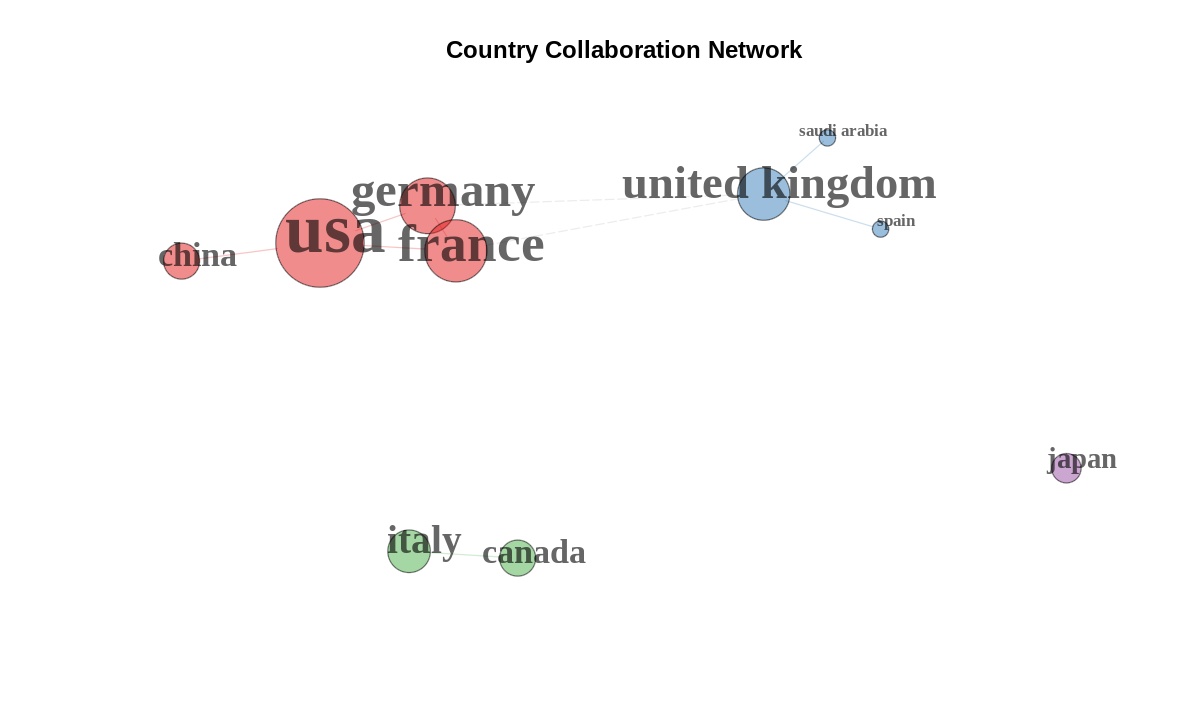

In [40]:
country_net_matrix <- biblioNetwork(data,
                                    analysis = "collaboration",
                                    network = "countries",
                                    sep = ";")
par(bg = "white")
networkPlot(country_net_matrix,
            n = 10,
            Title = "Country Collaboration Network",
            type = "fruchterman",
            size = TRUE,
            remove.multiple = FALSE,
            labelsize = 5,
            label.cex = TRUE)


### Word Cloud

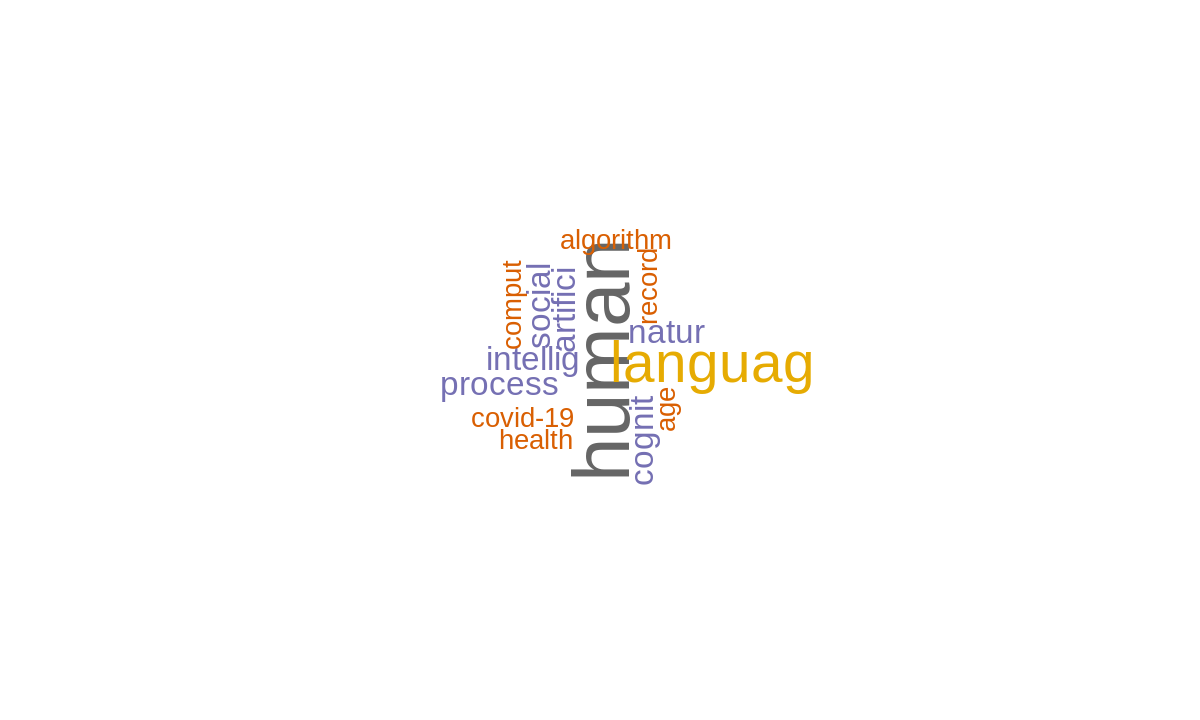

In [17]:
keywords_list <- strsplit(tolower(data$ID), ";")
keywords_vector <- unlist(keywords_list)
keywords_vector <- trimws(keywords_vector)
keywords_vector <- keywords_vector[keywords_vector != ""]

corpus <- Corpus(VectorSource(keywords_vector))

corpus <- tm_map(corpus, stripWhitespace)
corpus <- tm_map(corpus, removeWords, stopwords("english"))
corpus <- tm_map(corpus, stemDocument)

tdm <- TermDocumentMatrix(corpus)
tdm_matrix <- as.matrix(tdm)

word_freqs <- rowSums(tdm_matrix)
word_freqs <- sort(word_freqs, decreasing = TRUE)

set.seed(123)
par(bg = "white")
wordcloud(words = names(word_freqs), freq = word_freqs,
          max.words = 100, random.order = FALSE,
          colors = brewer.pal(8, "Dark2"),
          scale = c(4, 0.5),
          rot.per = 0.35)


### Collocations

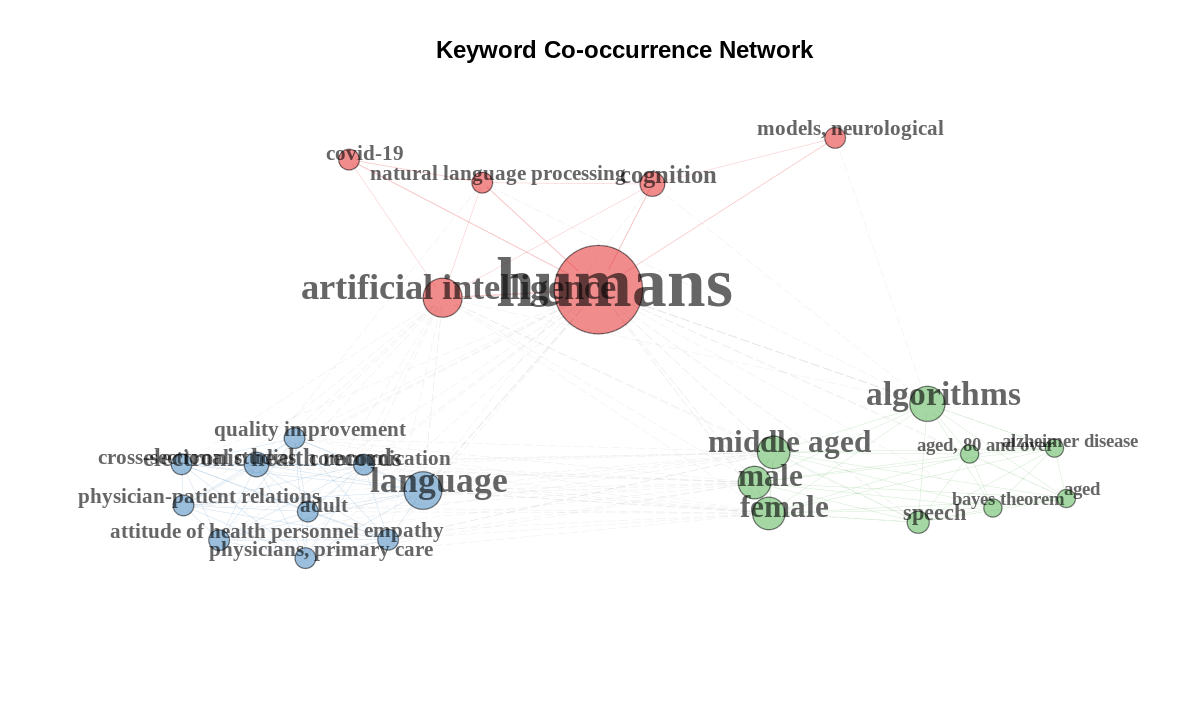

In [51]:
co_occurrence_matrix <- biblioNetwork(data, analysis = "co-occurrences",
                                      network = "keywords", sep = ";")
par(bg = "white")
net <- networkPlot(co_occurrence_matrix,
                   normalize = "association",
                   weighted = TRUE,
                   n = 25,
                   Title = "Keyword Co-occurrence Network",
                   type = "fruchterman",
                   size = TRUE,
                   labelsize = 5,
                   edgesize = 1,
                   label.cex = TRUE,
                   cluster = "louvain",
                   remove.isolates = TRUE)


### Now it's time for some LDA

      Topic 1    Topic 2   Topic 3    Topic 4      Topic 5    
 [1,] "languag"  "text"    "confer"   "brain"      "research" 
 [2,] "process"  "model"   "intern"   "neuron"     "book"     
 [3,] "use"      "simplif" "proceed"  "scienc"     "technolog"
 [4,] "speech"   "use"     "paper"    "doctrin"    "field"    
 [5,] "model"    "sentenc" "comput"   "cognit"     "educ"     
 [6,] "cultur"   "complex" "intellig" "human"      "communic" 
 [7,] "inform"   "evalu"   "system"   "book"       "develop"  
 [8,] "linguist" "system"  "held"     "neurosci"   "learn"    
 [9,] "method"   "generat" "part"     "theori"     "intellig" 
[10,] "analysi"  "task"    "applic"   "understand" "applic"   


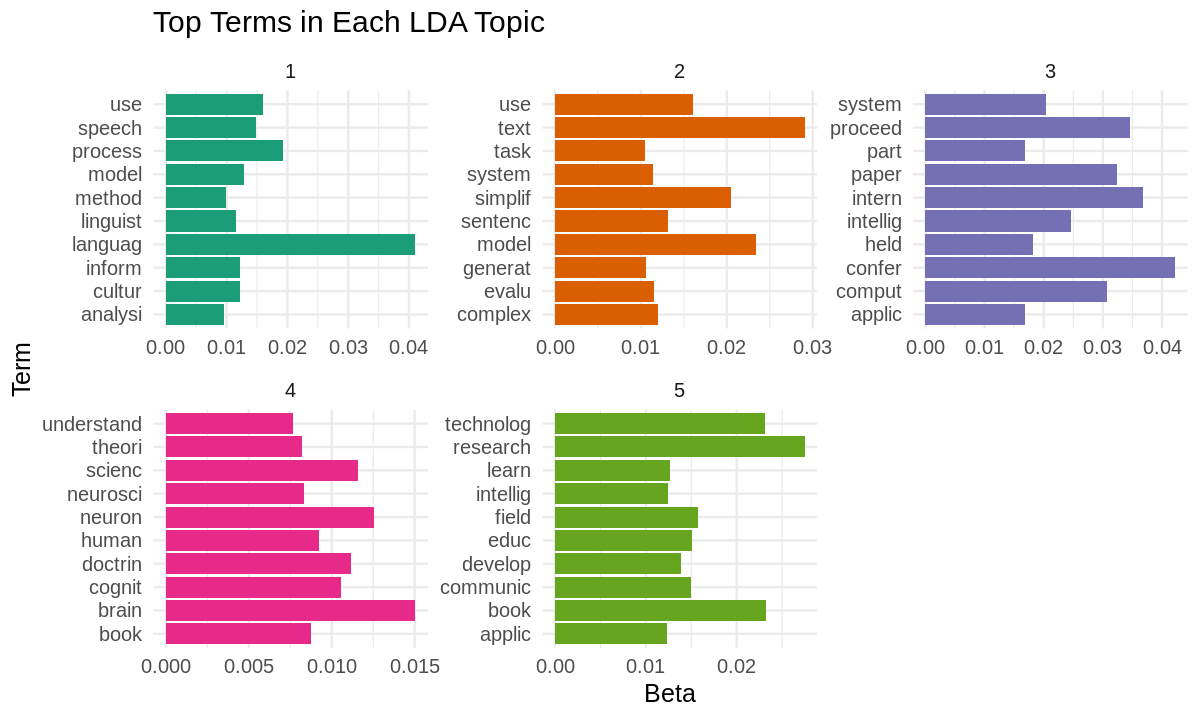

In [ ]:
documents <- paste(data$TI, data$AB, sep = " ")
documents <- tolower(documents)

corpus_tm <- Corpus(VectorSource(documents))

corpus_tm <- tm_map(corpus_tm, removePunctuation)
corpus_tm <- tm_map(corpus_tm, removeNumbers)
corpus_tm <- tm_map(corpus_tm, stripWhitespace)
corpus_tm <- tm_map(corpus_tm, removeWords, stopwords("english"))
corpus_tm <- tm_map(
  corpus_tm, content_transformer(function(x) gsub("[^\x01-\x7F]", "", x))
)
corpus_tm <- tm_map(corpus_tm, stemDocument)

dtm <- DocumentTermMatrix(corpus_tm)
dtm_sparse <- removeSparseTerms(dtm, 0.99)

row_totals <- apply(dtm_sparse, 1, sum)
dtm_final <- dtm_sparse[row_totals > 0, ]

k <- 5

set.seed(123)
lda_model <- LDA(dtm_final, k = k, control = list(seed = 123))

lda_terms <- terms(lda_model, 10)
print(lda_terms)

lda_topics <- topics(lda_model)

topics_terms <- tidy(lda_model, matrix = "beta")

top_terms <- topics_terms %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  arrange(topic, -beta)

ggplot(top_terms, aes(term, beta, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  coord_flip() +
  theme_minimal(base_size = 15) +
  theme(
    plot.background = element_rect(fill = "white", color = NA),
    panel.background = element_rect(fill = "white", color = NA)
  ) +
  labs(title = "Top Terms in Each LDA Topic",
       x = "Term",
       y = "Beta") +
  scale_fill_brewer(palette = "Dark2")


# Conclusion

There are a lot of research on speech and cognition: yet none of them research aphasia. Needless to say, there are no automated assistants for Russian language simplification for people with aphasia. 